In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
def phi(x):
    return norm.pdf(x)

def G(x):
    return 1-norm.cdf(x)

def M(x):
    return phi(x)/G(x)


def v1(x):
    return M(x)
    
def v2(x):
    return 1/(M(x)-x)

def v3(x):
    return (2*M(x) - 2*x)/(x**2 + 1 - x*M(x))


def f1(x, delta, c = np.e):
    return x + (v1(x) - x)*G(v1(x))*(c/delta)

def f2(x, delta, c = np.e**2/2):
    return x + (v2(x) - x)*G(v2(x))*(c/delta)

def f3(x, delta, c = 2*np.e**3/9):
    return x + (v3(x) - x)*G(v3(x))*(c/delta)

def A(x, delta):
    return (np.log(1/delta) + x**2 / 2)/x

def f_subg(delta):
    return np.sqrt(2 *np.log(1/delta))

def g(delta):
    return norm.ppf(1-delta)

/var/folders/6l/5fsz8v5s73d453t40st4csy80000gn/T/ipykernel_5888/2819639043.py:31: RuntimeWarning: divide by zero encountered in divide
  return (np.log(1/delta) + x**2 / 2)/x


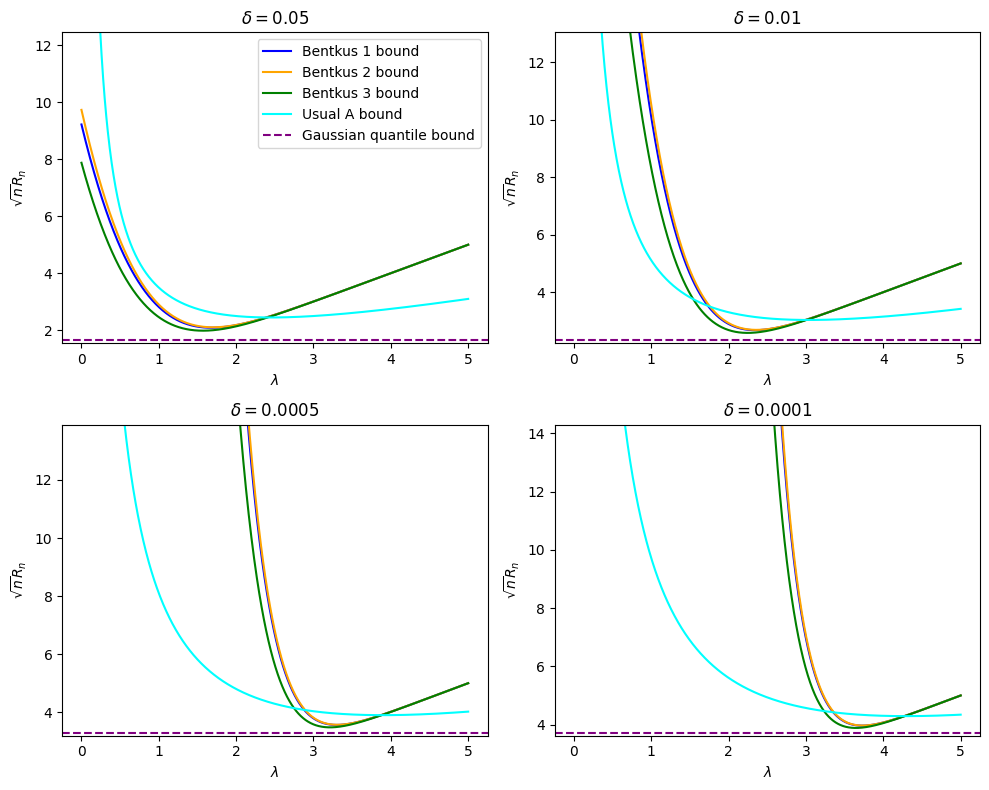

In [3]:
import numpy as np
import matplotlib.pyplot as plt

deltas = [0.05, 0.01, 0.0005, 0.0001]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

x = np.linspace(0, 5, 1000)
epsilon = 10

for ax, delta in zip(axes, deltas):
    
    y = f1(x, delta)
    ax.plot(x, y, label="Bentkus 1 bound", color='blue')
    
    y = f2(x, delta)
    ax.plot(x, y, label="Bentkus 2 bound", color='orange')
    
    y = f3(x, delta)
    ax.plot(x, y, label="Bentkus 3 bound", color='green')
    
    y = A(x, delta)
    ax.plot(x, y, label="Usual A bound", color='cyan')
    
    # Optional sub-Gaussian line
    # ax.axhline(f_subg(delta), label="Sub-Gaussian bound", color='red', linestyle='--')
    
    ax.axhline(g(delta), label="Gaussian quantile bound", color='purple', linestyle='--')
    
    ax.set_xlabel(r'$\lambda$')
    ax.set_ylabel(r'$\sqrt{n}R_n$')
    ax.set_title(rf"$\delta = {delta}$")
    ax.set_ylim(g(delta)-.1, f_subg(delta)+epsilon)

axes[0].legend()

plt.tight_layout()
plt.savefig("bounds_plot.png", dpi=300)
plt.show()

(2.2263478740408407, 13.034854258770293)

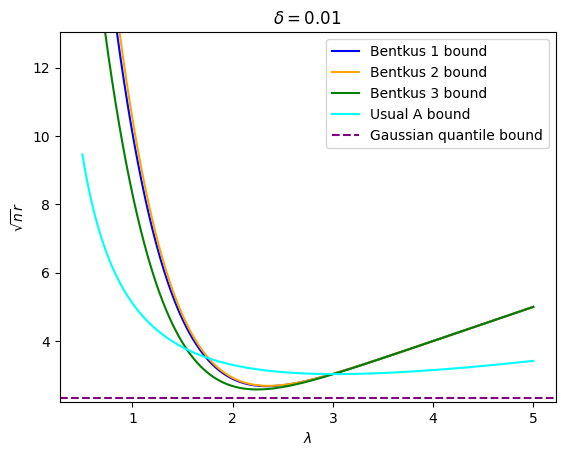

In [12]:
delta = 0.01
x = np.linspace(.5, 5, 1000)
y = f1(x, delta)
plt.plot(x, y, label="Bentkus 1 bound", color='blue')
y = f2(x, delta)
plt.plot(x, y, label="Bentkus 2 bound", color='orange')
y = f3(x, delta)
plt.plot(x, y, label="Bentkus 3 bound", color='green')
y = A(x, delta)
plt.plot(x, y, label="Usual A bound", color='cyan')


#y = f_subg(delta)
#plt.axhline(y, label="Sub-Gaussian bound", color='red', linestyle='--')
y = g(delta)
plt.axhline(y, label="Gaussian quantile bound", color='purple', linestyle='--')
plt.legend()
plt.xlabel(r'$\lambda$')
plt.ylabel(r'$\sqrt{n}r$')
plt.title(rf"$\delta = {delta}$ ")
epsilon = 10
plt.ylim(g(delta)-.1, f_subg(delta)+epsilon)

In [29]:
delta = 0.0000001
x = np.linspace(1, 8, 1000)
y = f(x, delta)
plt.plot(x, y, label="Bentkus bound")
plt.xlabel('x')
plt.ylabel('f(x)')
plt.axhline(y = f_subg(delta), color = 'r', linestyle = '--', label='Sub-Gaussian Bound')
plt.axhline(y = g(x, delta), color = 'g', linestyle = '--', label='Gaussian Bound')
plt.legend()
epsilon = 0.1
plt.ylim(g(x, delta)-epsilon, f_subg(delta)+epsilon)

NameError: name 'f' is not defined